# EDA & Data Engineering — Heat Pump Load Forecasting (Task 3)

## 0. Setup & Imports

In [3]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

DATA_PATH    = "data/data.csv"
DEVICES_PATH = "data/devices.csv"
SAMPLE_FRAC  = 0.10
RANDOM_SEED  = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Imports OK")

Imports OK


## 1. Data Loading (Memory-Safe)

In [4]:
devices = pd.read_csv(DEVICES_PATH)
print(f"devices.csv — {devices.shape[0]} rows, {devices.shape[1]} cols")
devices.head()

devices.csv — 600 rows, 3 cols


,latitude,longitude,deviceId
0,50.0,18.3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
1,53.5,21.1,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...
2,52.9,18.1,01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2...
3,52.5,17.7,01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfc...
4,50.7,16.7,02e4ad5d8d0016d35a003ea6df7e10fe27093aba81c64a...


In [5]:
# Stratified sample: read in 500K-row chunks, keep 10% of each
CHUNK = 500_000
chunks = []

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK, low_memory=False):
    sampled = chunk.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
    chunks.append(sampled)

df = pd.concat(chunks, ignore_index=True)
del chunks

# Parse timedate (format: '2024-10-01 00:00:00 UTC')
df["timedate"] = pd.to_datetime(df["timedate"].str.replace(" UTC", "", regex=False), utc=True)

# Categorical dtypes
df["deviceType"] = df["deviceType"].astype("category")
df["x3"]         = df["x3"].astype("category")

# Merge device metadata
df = df.merge(devices[["deviceId", "latitude", "longitude"]], on="deviceId", how="left")

print(f"Sampled rows: {df.shape[0]:,}  | Columns: {df.shape[1]}")
print(f"Period distribution:\n{df['period'].value_counts().to_string()}")

Sampled rows: 6,449,732  | Columns: 22
Period distribution:
period
train    3465680
test     1979599
valid    1004453


In [6]:
print(df.dtypes)
df.head(3)

deviceId                      str
timedate      datetime64[us, UTC]
period                        str
t1                        float64
t2                        float64
t3                        float64
t4                        float64
t5                        float64
t6                        float64
t7                        float64
t8                        float64
t9                        float64
t10                       float64
t11                       float64
t12                       float64
t13                       float64
x1                        float64
x2                        float64
x3                       category
deviceType               category
latitude                  float64
longitude                 float64
dtype: object


,deviceId,timedate,period,t1,t2,t3,t4,t5,t6,t7,...,t10,t11,t12,t13,x1,x2,x3,deviceType,latitude,longitude
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-09-29 09:05:00+00:00,test,0.31,0.05,0.0,0.36,0.45,0.44,0.21,...,0.21,0.21,0.07,0.07,0.0,NaN,8,19,50.0,18.3
1,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...,2025-09-16 20:45:00+00:00,test,0.32,0.04,0.0,0.52,0.53,0.47,0.18,...,0.21,0.21,0.07,0.08,0.0,NaN,7,11,53.5,21.1
2,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...,2025-01-07 08:15:00+00:00,train,0.27,0.04,0.0,0.31,0.43,0.41,0.21,...,0.20,0.20,0.06,0.07,0.0,0.0,7,11,53.5,21.1


## 2. Basic EDA

In [44]:
train = df[df["period"] == "train"]

In [41]:
train.describe()

,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,...,t12,t13,x1,x2,latitude,longitude,geo_cluster,month,hour,day_of_week
count,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,...,3.465680e+06,3.465680e+06,3465680.0,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06,3.465680e+06
mean,2.803890e-01,4.533934e-02,4.668931e-03,3.915269e-01,4.353877e-01,4.155280e-01,2.104768e-01,5.142438e-01,3.912095e-01,2.065708e-01,...,6.438838e-02,6.697523e-02,0.0,1.578692e-01,5.214401e+01,1.852989e+01,2.255276e+00,6.178126e+00,1.151571e+01,2.985856e+00
std,3.593751e-02,6.178111e-03,6.262531e-02,7.405801e-02,5.178189e-02,4.435877e-02,3.496309e-02,3.442246e-02,7.099413e-02,5.591191e-03,...,7.441539e-03,8.434562e-03,0.0,2.265349e-01,1.443051e+00,2.064218e+00,1.639214e+00,4.326817e+00,6.922798e+00,1.996877e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e-01,0.000000e+00,1.100000e-01,4.300000e-01,0.000000e+00,1.800000e-01,...,4.000000e-02,0.000000e+00,0.0,0.000000e+00,4.940000e+01,1.440000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.600000e-01,4.000000e-02,0.000000e+00,3.300000e-01,4.100000e-01,3.900000e-01,2.000000e-01,4.800000e-01,3.600000e-01,2.000000e-01,...,6.000000e-02,6.000000e-02,0.0,0.000000e+00,5.100000e+01,1.700000e+01,1.000000e+00,2.000000e+00,6.000000e+00,1.000000e+00
50%,2.800000e-01,5.000000e-02,0.000000e+00,3.900000e-01,4.400000e-01,4.200000e-01,2.100000e-01,5.200000e-01,3.900000e-01,2.100000e-01,...,7.000000e-02,7.000000e-02,0.0,2.365174e-03,5.220000e+01,1.860000e+01,2.000000e+00,4.000000e+00,1.200000e+01,3.000000e+00
75%,3.000000e-01,5.000000e-02,0.000000e+00,4.500000e-01,4.700000e-01,4.500000e-01,2.100000e-01,5.400000e-01,4.100000e-01,2.100000e-01,...,7.000000e-02,7.000000e-02,0.0,2.459781e-01,5.330000e+01,2.000000e+01,4.000000e+00,1.100000e+01,1.800000e+01,5.000000e+00
max,1.000000e+00,1.600000e-01,1.000000e+00,1.000000e+00,8.400000e-01,7.400000e-01,4.500000e-01,7.400000e-01,9.000000e-01,2.400000e-01,...,1.000000e-01,1.300000e-01,0.0,1.389066e+01,5.510000e+01,2.390000e+01,5.000000e+00,1.200000e+01,2.300000e+01,6.000000e+00


In [39]:
valid.head()

,deviceId,timedate,period,t1,t2,t3,t4,t5,t6,t7,...,x2_lag_1,x2_lag_12,x2_lag_288,x2_roll_mean_12,x2_roll_std_12,x2_roll_mean_288,t1_roll_mean_12,device_mean_x2,device_std_x2,year_month
6105,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-05-01 00:55:00+00:00,valid,0.33,0.05,0.0,0.34,0.38,0.37,0.2,...,0.0,0.0,0.0,0.0,0.0,0.035291,0.347500,0.190536,0.200945,2025-05
6106,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-05-01 01:25:00+00:00,valid,0.32,0.05,0.0,0.34,0.37,0.37,0.2,...,NaN,0.0,0.0,0.0,0.0,0.035414,0.344167,0.190536,0.200945,2025-05
6107,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-05-01 01:55:00+00:00,valid,0.32,0.05,0.0,0.33,0.37,0.36,0.2,...,NaN,0.0,0.0,0.0,0.0,0.035538,0.340000,0.190536,0.200945,2025-05
6108,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-05-01 03:35:00+00:00,valid,0.32,0.05,0.0,0.34,0.39,0.39,0.2,...,NaN,0.0,0.0,0.0,0.0,0.035663,0.335833,0.190536,0.200945,2025-05
6109,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-05-01 04:00:00+00:00,valid,0.32,0.05,0.0,0.33,0.39,0.38,0.2,...,NaN,0.0,0.0,0.0,0.0,0.035788,0.333333,0.190536,0.200945,2025-05


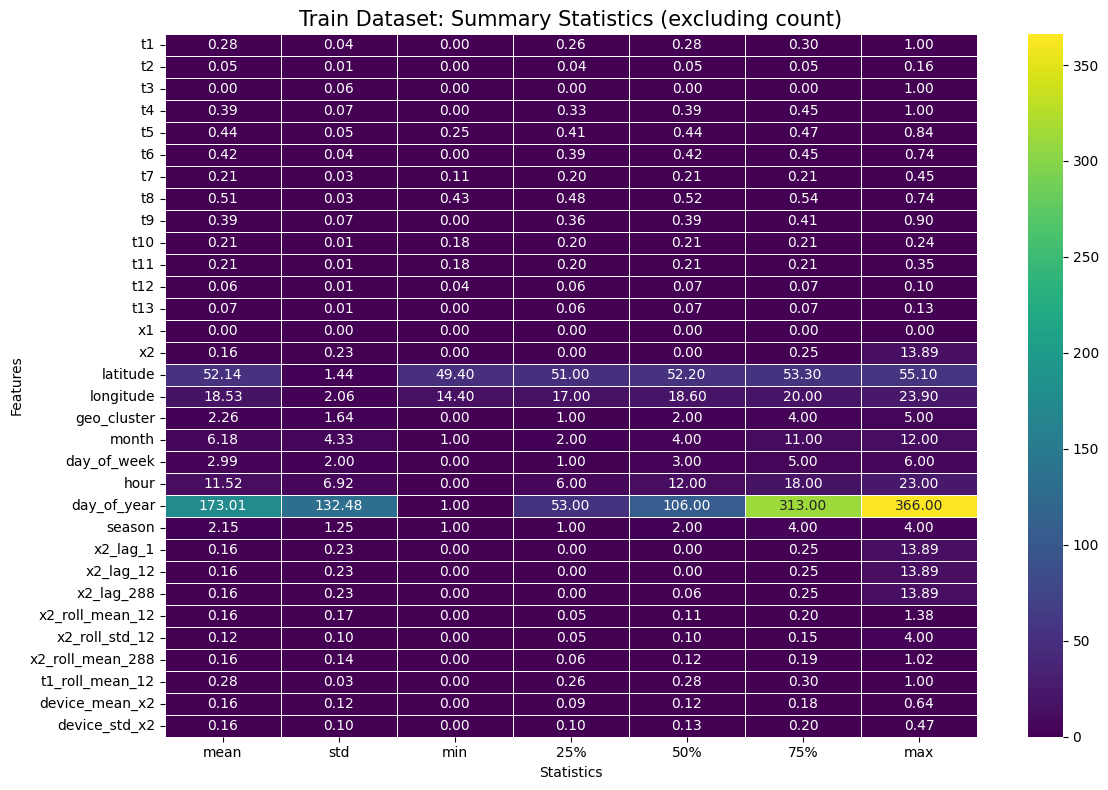

In [45]:
train_stats = train.describe().T.drop(columns=['count'])

plt.figure(figsize=(12, 8))
sns.heatmap(train_stats, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Train Dataset: Summary Statistics (excluding count)', fontsize=15)
plt.xlabel('Statistics')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

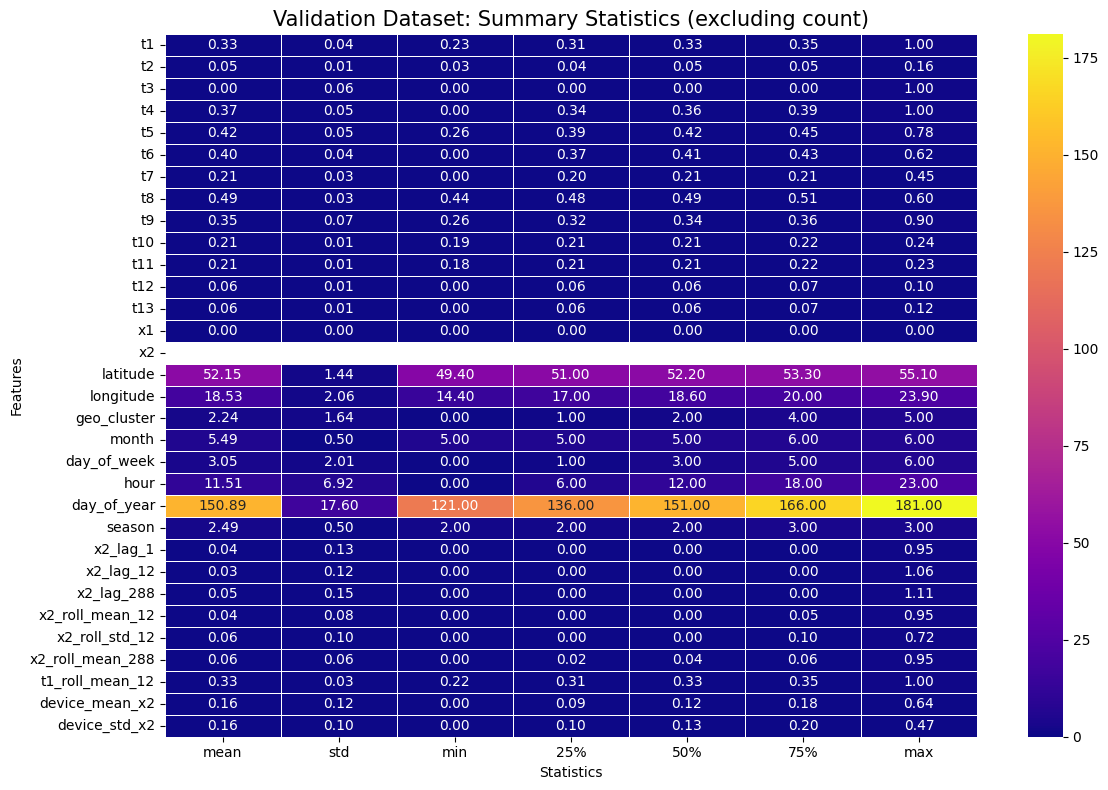

In [43]:
# Visualizing the validation split statistics
valid_stats = valid.describe().T.drop(columns=['count'])

plt.figure(figsize=(12, 8))
sns.heatmap(valid_stats, annot=True, cmap='plasma', fmt=".2f", linewidths=0.5)
plt.title('Validation Dataset: Summary Statistics (excluding count)', fontsize=15)
plt.xlabel('Statistics')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

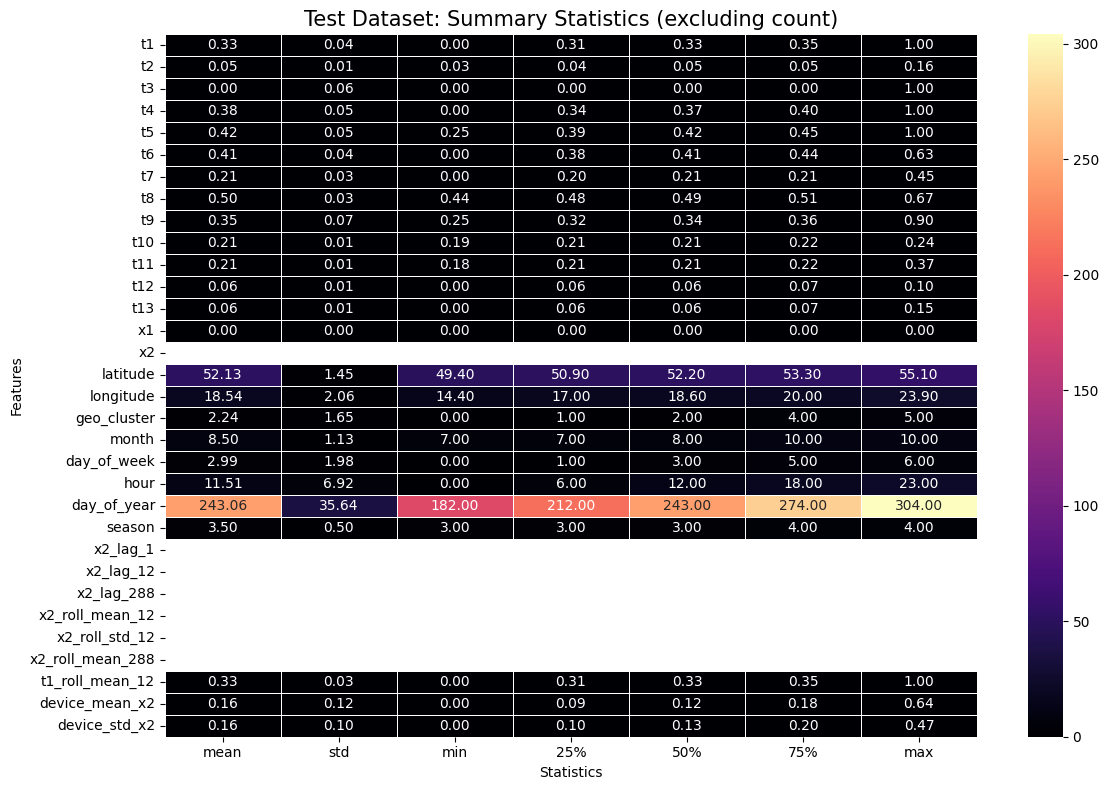

In [46]:
# Visualizing the test split statistics
test_stats = test.describe().T.drop(columns=['count'])

plt.figure(figsize=(12, 8))
sns.heatmap(test_stats, annot=True, cmap='magma', fmt=".2f", linewidths=0.5)
plt.title('Test Dataset: Summary Statistics (excluding count)', fontsize=15)
plt.xlabel('Statistics')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

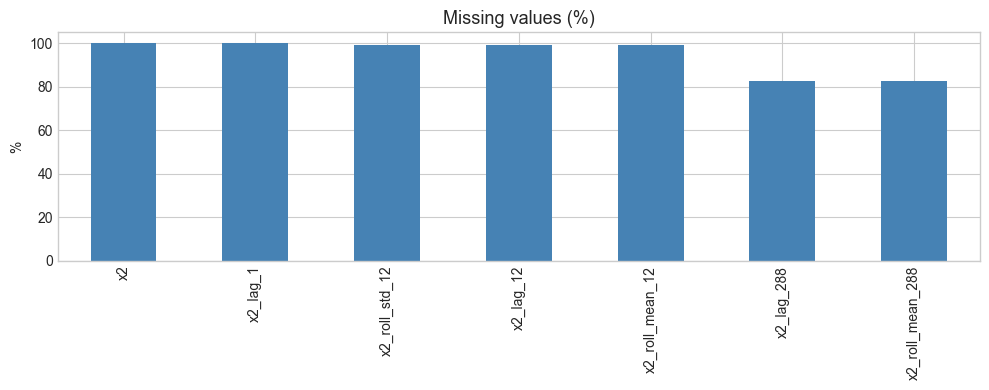

,count,mean,std,min,25%,50%,75%,max
t1,6449732.0,0.3045,0.0444,0.00,0.2700,0.3000,0.3300,1.0000
t2,6449732.0,0.0462,0.0064,0.00,0.0400,0.0500,0.0500,0.1600
t3,6449732.0,0.0046,0.0623,0.00,0.0000,0.0000,0.0000,1.0000
t4,6449732.0,0.3836,0.0650,0.00,0.3400,0.3700,0.4300,1.0000
t5,6449732.0,0.4272,0.0508,0.25,0.4000,0.4300,0.4600,1.0000
t6,6449732.0,0.4107,0.0445,0.00,0.3800,0.4200,0.4400,0.7400
t7,6449732.0,0.2107,0.0344,0.00,0.2000,0.2100,0.2100,0.4500
t8,6449732.0,0.5054,0.0321,0.43,0.4800,0.5000,0.5300,0.7400
t9,6449732.0,0.3735,0.0738,0.00,0.3300,0.3600,0.4000,0.9000
t10,6449732.0,0.2096,0.0063,0.18,0.2100,0.2100,0.2100,0.2400


In [34]:
# Missing values
missing_pct = df[df["period"] == "valid"].isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct):
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_pct.plot.bar(ax=ax, color="steelblue")
    ax.set_title("Missing values (%)")
    ax.set_ylabel("%")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# Basic stats table
num_cols = df.select_dtypes(include="number").columns.tolist()
df[num_cols].describe().T.round(4)

Unique devices: 600


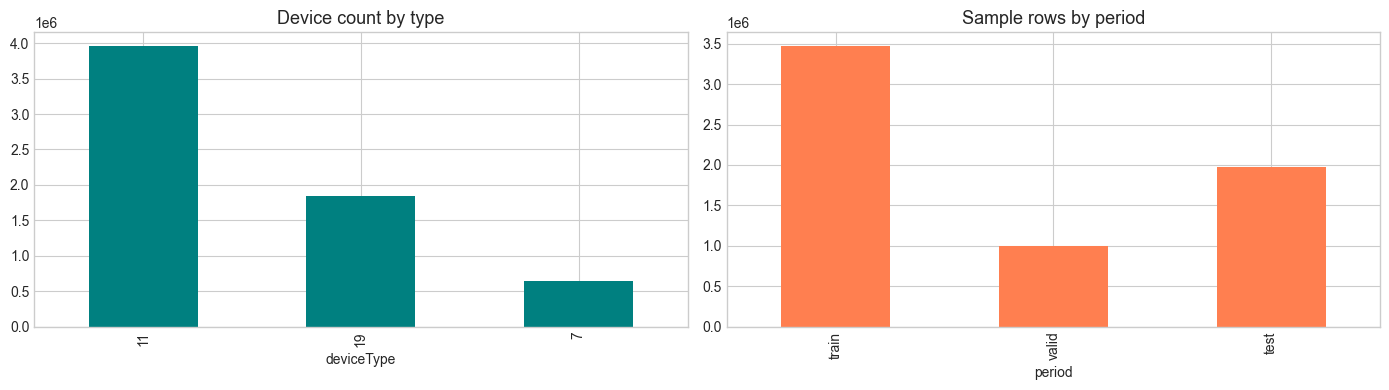

In [8]:
print(f"Unique devices: {df['deviceId'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["deviceType"].value_counts().plot.bar(ax=axes[0], color="teal")
axes[0].set_title("Device count by type")
axes[0].set_xlabel("deviceType")

df["period"].value_counts().reindex(["train", "valid", "test"]).plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Sample rows by period")
plt.tight_layout()
plt.show()

## 3. Target Variable (x2) Analysis

Train rows: 3,465,680


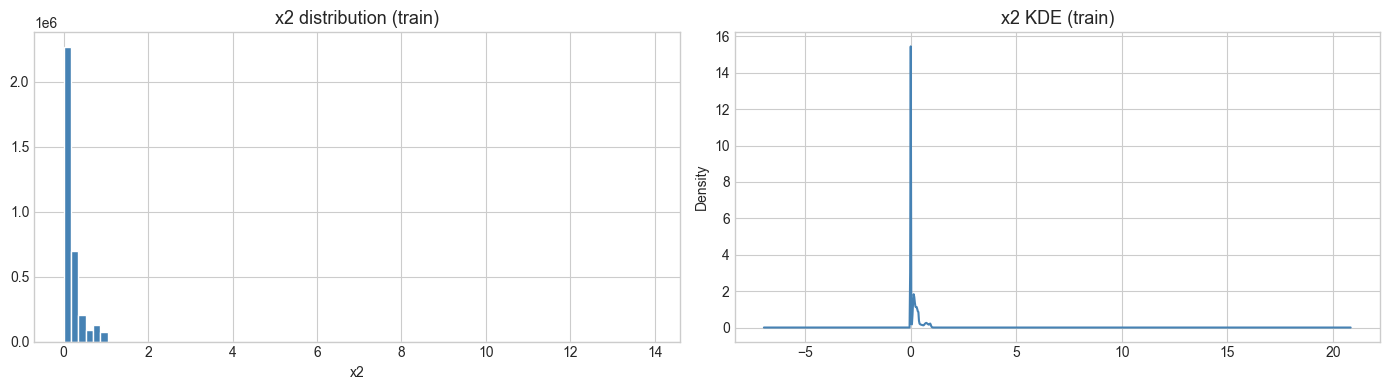

In [9]:
train = df[df["period"] == "train"].copy()
print(f"Train rows: {len(train):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train["x2"].hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("x2 distribution (train)")
axes[0].set_xlabel("x2")

train["x2"].plot.kde(ax=axes[1], color="steelblue")
axes[1].set_title("x2 KDE (train)")
plt.tight_layout()
plt.show()

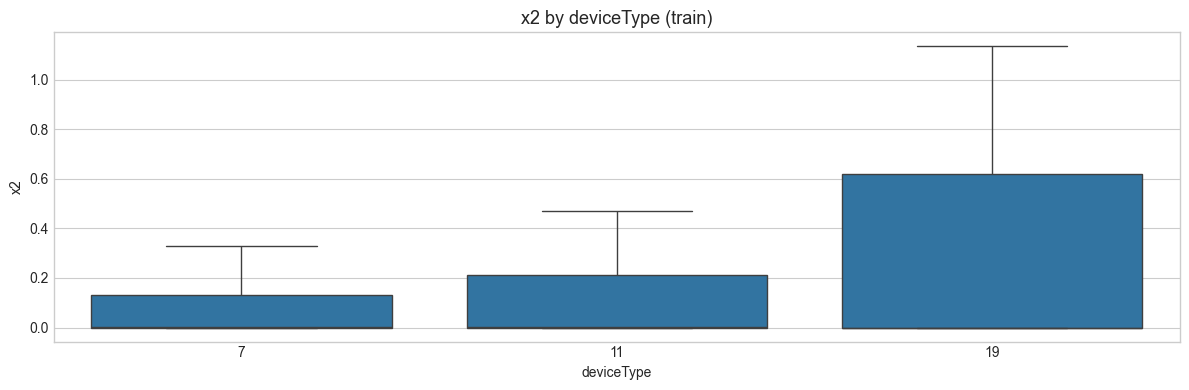

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=train, x="deviceType", y="x2", ax=ax, showfliers=False)
ax.set_title("x2 by deviceType (train)")
ax.set_xlabel("deviceType")
plt.tight_layout()
plt.show()

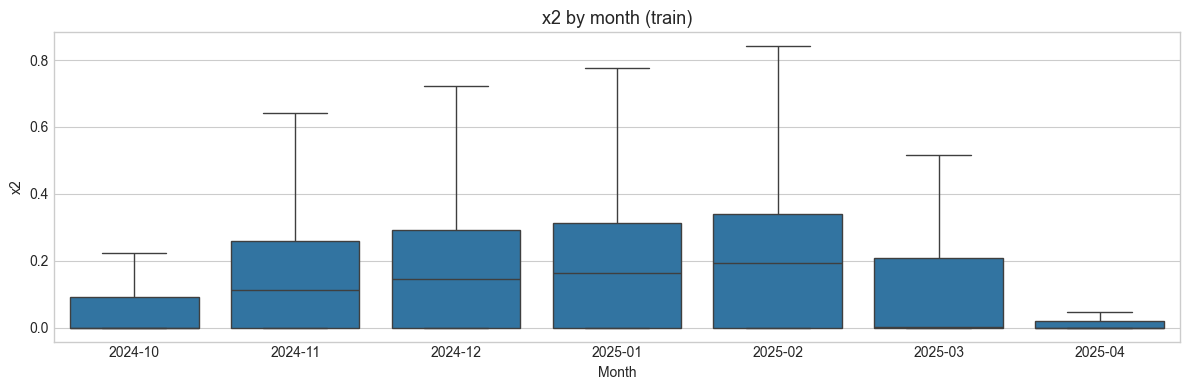

In [11]:
train["month"] = train["timedate"].dt.month
train["hour"]  = train["timedate"].dt.hour
train["month_label"] = train["timedate"].dt.to_period("M").astype(str)
month_order = sorted(train["month_label"].unique())

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=train, x="month_label", y="x2", order=month_order, ax=ax, showfliers=False)
ax.set_title("x2 by month (train)")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

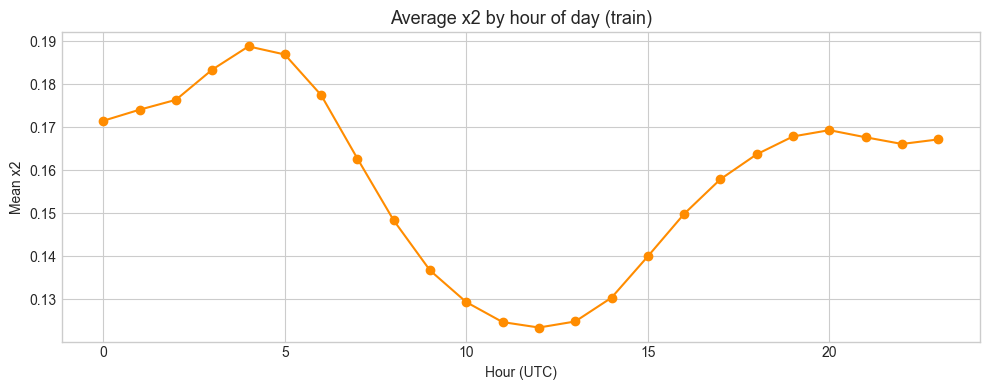

In [12]:
hourly_avg = train.groupby("hour")["x2"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
hourly_avg.plot(ax=ax, marker="o", color="darkorange")
ax.set_title("Average x2 by hour of day (train)")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Mean x2")
plt.tight_layout()
plt.show()

In [13]:
dev_means = train.groupby("deviceId")["x2"].mean().sort_values()
print("Bottom-10 devices (mean x2):")
print(dev_means.head(10).to_string())
print("\nTop-10 devices (mean x2):")
print(dev_means.tail(10).to_string())

Bottom-10 devices (mean x2):
deviceId
a4a44e2949a7db0f951ac94a601a1db2f5d993bcebb465efff7b810475161e17    0.000000
e5d0949a59a0e5a2f854d1da2e668bd9926cb00e55c9abf8660bdcf75bec29d5    0.003939
2783c80382125f5fa4b8f085257d7c59ec7e5971a893809d6834627d183e7564    0.004508
84088011a5445196a0d121760f03c4b58b7f357eb2342604f34b471efde637a6    0.007055
93994583a213359d175a517cecd0a77ce5d37e9d4d91b5a1965f037bb218cafc    0.012998
68f47e7f7e22a510cce68978eaa4c4234dd9a420465b7beeb1587ef04a7723b2    0.013744
b6b5f765ecb2db140065fca2e86999f822b7c7b2cbd4df0e558d2eac3090fb5b    0.018427
6fa817294f5b18334e9e73c5452cf2a6cbc144215fcd05dd284650588a3e21e2    0.018661
9020d74cfc53a2caed885b6d6c8f95474aa7a5ad02569e4bfc778ec75e7559c4    0.021483
a589f5aa2e5bc12a9d6bc033396484da47eaad8f5fcea21a08ab0a69391cc61b    0.021721

Top-10 devices (mean x2):
deviceId
3b4a3a48242c58022ffcedf96c284b20cf360dcff974b14716a36a4e5115389e    0.552870
205b5419584613fbd563122b584157c97778bee6421a23bcbd498361cf710cd5    0.564191
19

## 4. Temporal Analysis

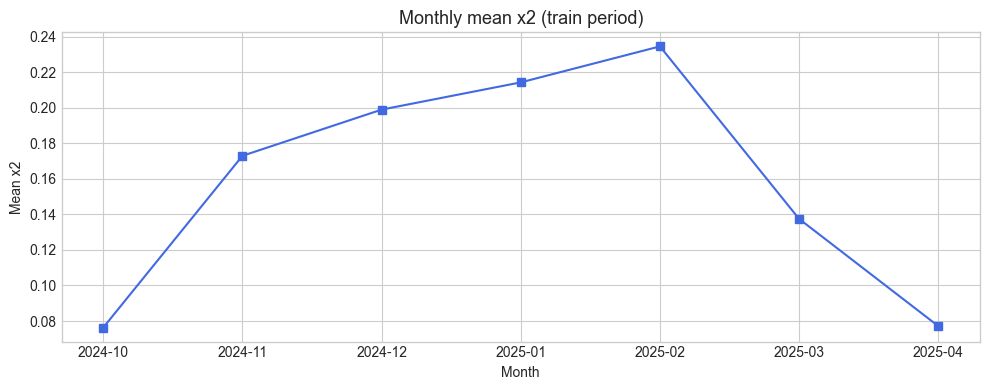

In [14]:
monthly = train.groupby("month_label")["x2"].mean().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker="s", color="royalblue")
ax.set_title("Monthly mean x2 (train period)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean x2")
plt.tight_layout()
plt.show()

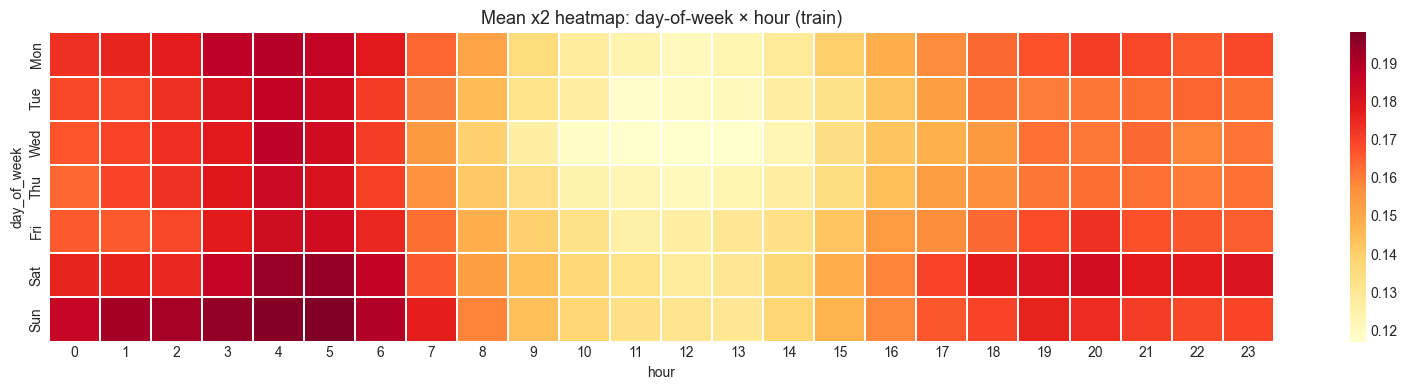

In [15]:
train["day_of_week"] = train["timedate"].dt.dayofweek
pivot = train.pivot_table(values="x2", index="day_of_week", columns="hour", aggfunc="mean")

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
            yticklabels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_title("Mean x2 heatmap: day-of-week × hour (train)")
plt.tight_layout()
plt.show()

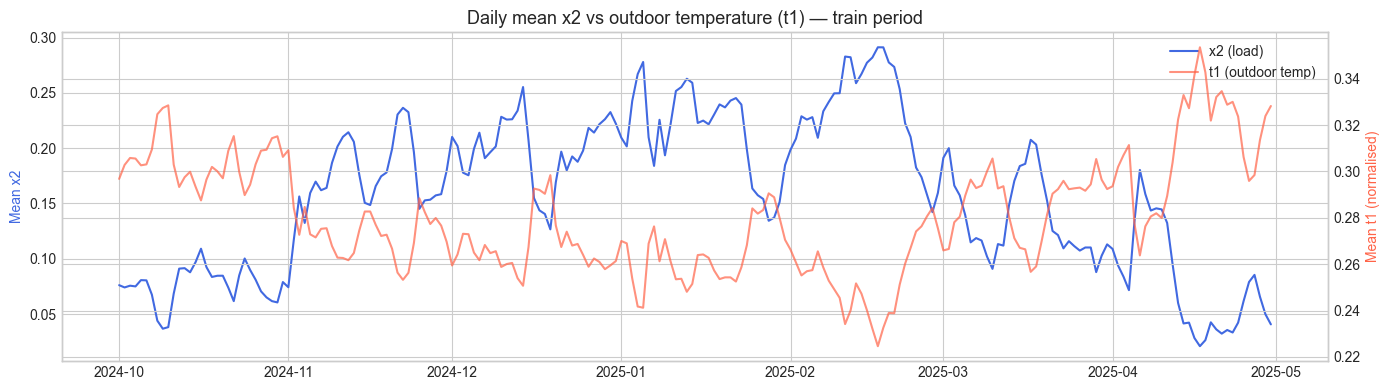

In [16]:
daily = train.set_index("timedate").resample("D")[["x2", "t1"]].mean()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(daily.index, daily["x2"], color="royalblue",  label="x2 (load)")
ax2.plot(daily.index, daily["t1"], color="tomato",     label="t1 (outdoor temp)", alpha=0.7)
ax1.set_ylabel("Mean x2", color="royalblue")
ax2.set_ylabel("Mean t1 (normalised)", color="tomato")
ax1.set_title("Daily mean x2 vs outdoor temperature (t1) — train period")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.show()

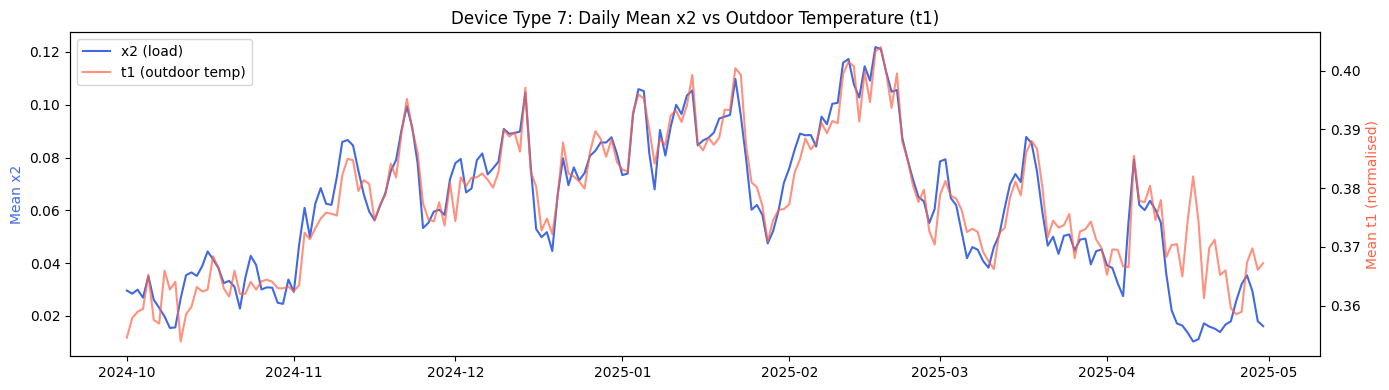

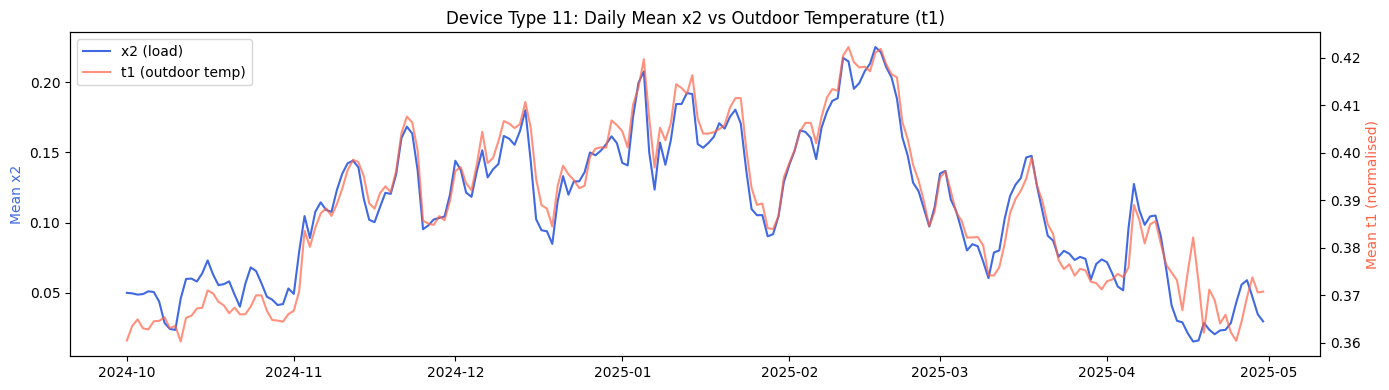

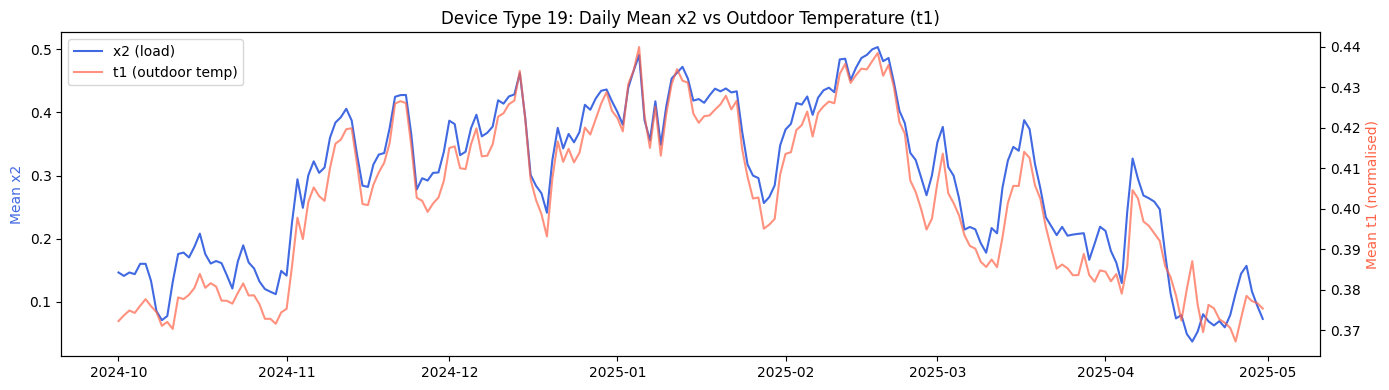

In [58]:
# Ensure timedate is in datetime format before processing
train['timedate'] = pd.to_datetime(train['timedate'])
tested_t = "t4"

# Iterate through each unique device type
for device_type, group in train.groupby('deviceType'):
    # Resample the specific group to daily mean
    daily = group.set_index("timedate").resample("D")[["x2", tested_t]].mean()

    # Create the figure and dual axes
    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()

    # Plot data
    ax1.plot(daily.index, daily["x2"], color="royalblue", label="x2 (load)")
    ax2.plot(daily.index, daily[tested_t], color="tomato", label="t1 (outdoor temp)", alpha=0.7)

    # Formatting
    ax1.set_ylabel("Mean x2", color="royalblue")
    ax2.set_ylabel("Mean t1 (normalised)", color="tomato")
    ax1.set_title(f"Device Type {device_type}: Daily Mean x2 vs Outdoor Temperature (t1)")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

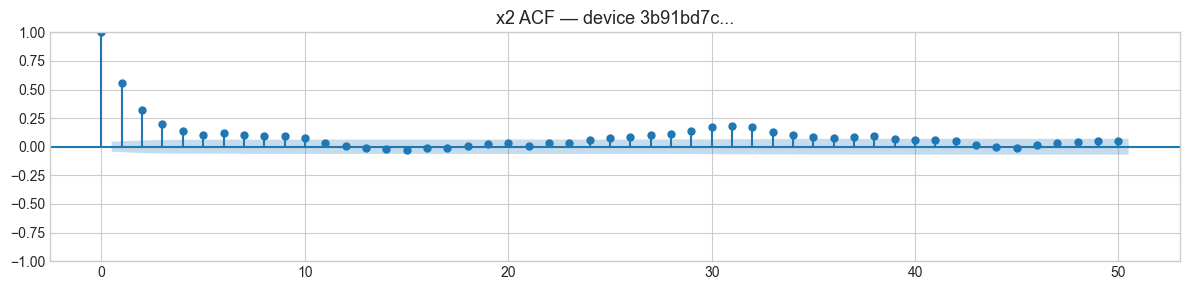

In [17]:
# ACF for a sample device
try:
    from statsmodels.graphics.tsaplots import plot_acf
    sample_dev = train["deviceId"].value_counts().index[0]
    dev_series = (
        train[train["deviceId"] == sample_dev]
        .sort_values("timedate")["x2"]
        .dropna()
        .head(2000)
    )
    fig, ax = plt.subplots(figsize=(12, 3))
    plot_acf(dev_series, lags=50, ax=ax, title=f"x2 ACF — device {sample_dev[:8]}...")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("statsmodels not installed — skipping ACF plot")

## 5. Temperature Feature Analysis

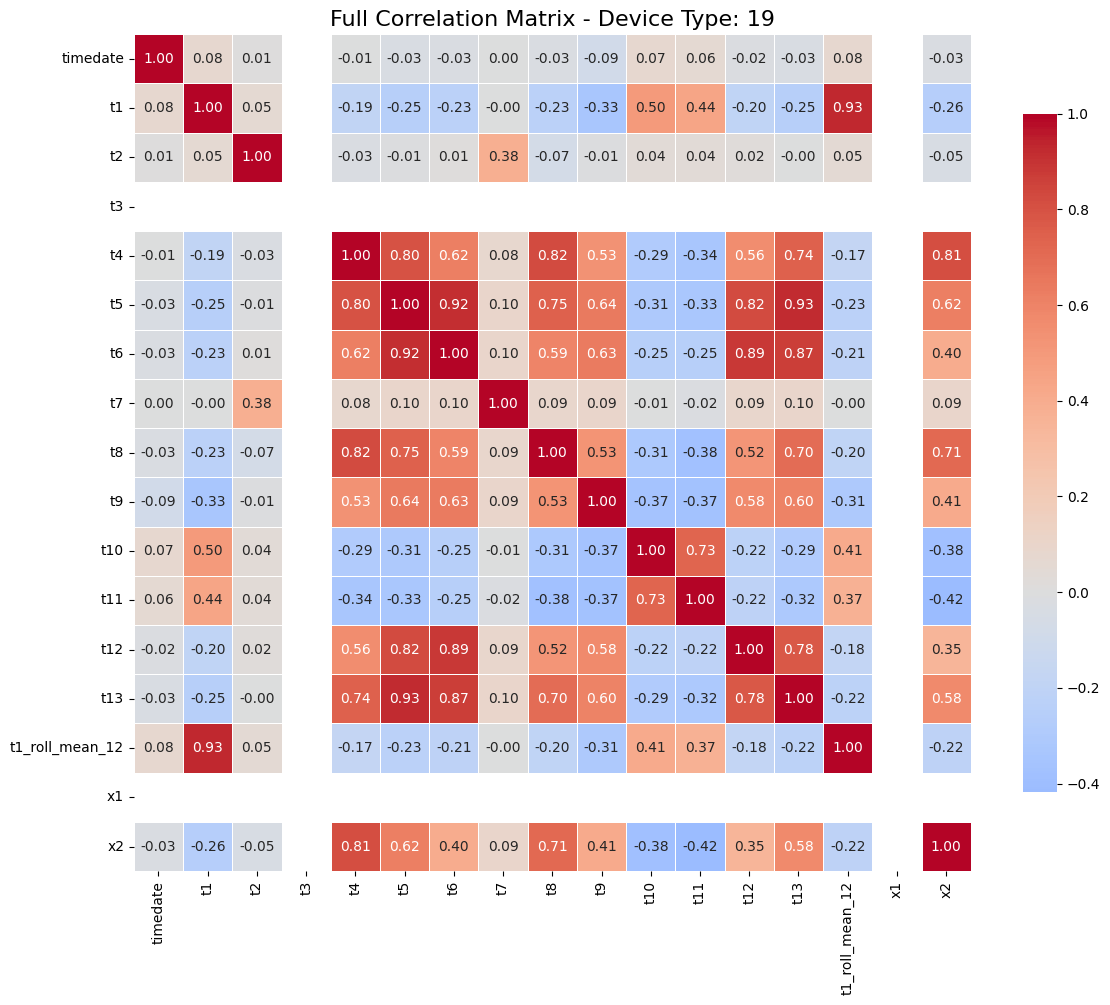

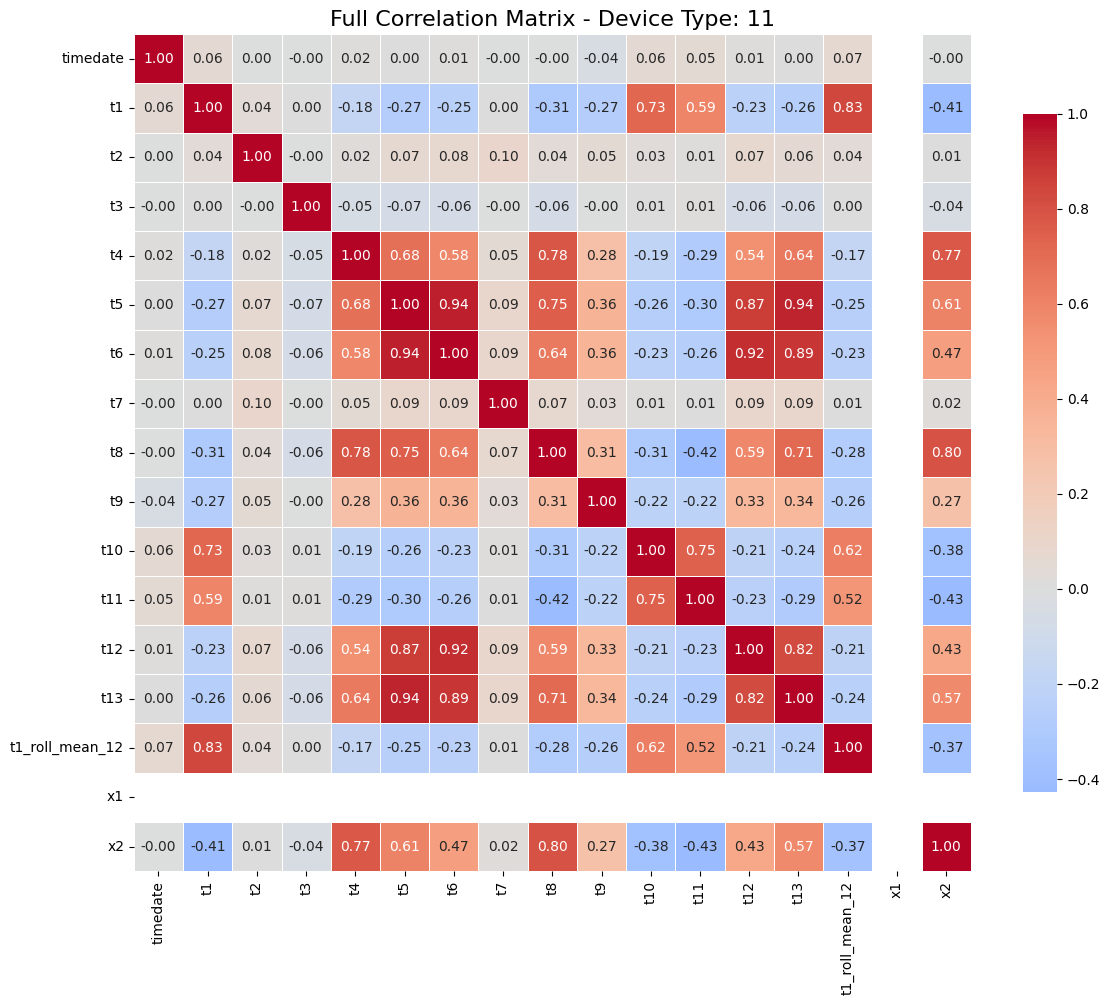

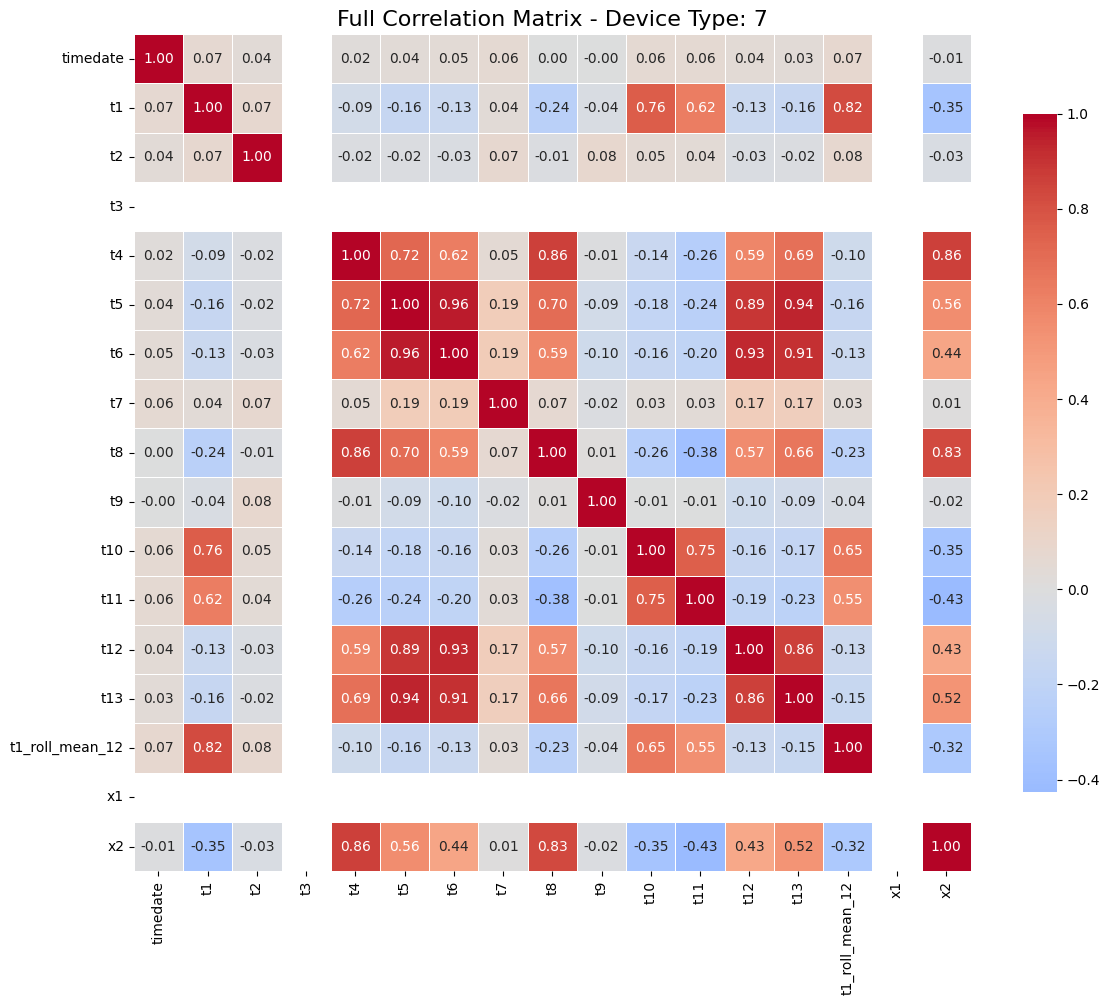

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Identify relevant columns (t-sensors, x1, and x2)
t_cols = [c for c in train.columns if c.startswith("t")] + ["x1", "x2"]
# Ensure we only use numeric columns present in the data
t_cols = [c for c in t_cols if c in train.columns and train[c].dtype not in ["object", "category"]]

# 2. Get unique device types (picking the first 3 available)
unique_types = train['deviceType'].unique()[:3]

# 3. Generate a plot for each device type
for d_type in unique_types:
    # Filter data for the specific device type
    type_data = train[train['deviceType'] == d_type][t_cols]

    if type_data.empty:
        continue

    # Calculate the full correlation matrix
    corr = type_data.corr()

    # Create the figure
    plt.figure(figsize=(12, 10))

    # Plot the full matrix (removed the mask for "full matrix" requirement)
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": .8}
    )

    plt.title(f"Full Correlation Matrix - Device Type: {d_type}", fontsize=16)
    plt.tight_layout()
    plt.show()

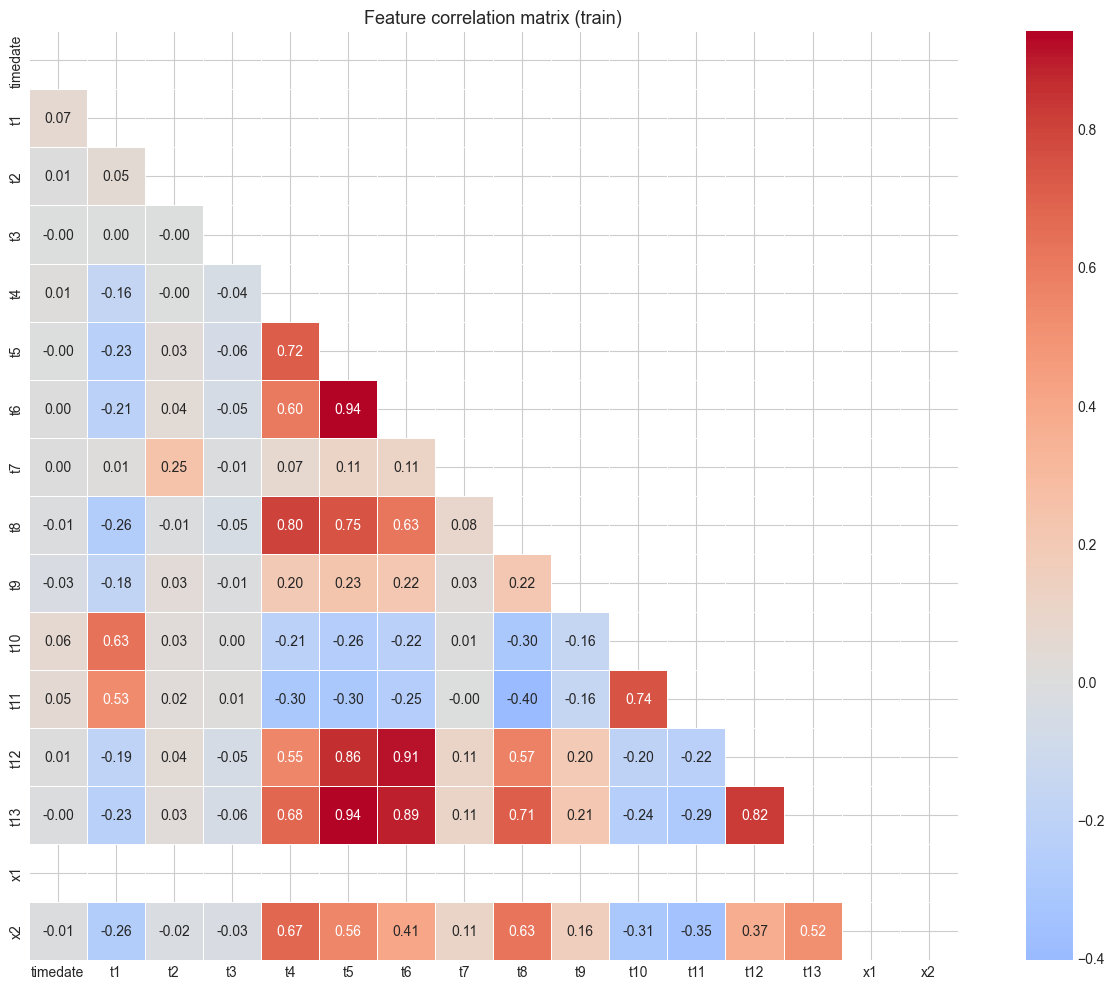

In [18]:
t_cols = [c for c in df.columns if c.startswith("t")] + ["x1", "x2"]
t_cols = [c for c in t_cols if c in df.columns and df[c].dtype not in ["object", "category"]]

fig, ax = plt.subplots(figsize=(14, 10))
corr = train[t_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.5, square=True)
ax.set_title("Feature correlation matrix (train)")
plt.tight_layout()
plt.show()

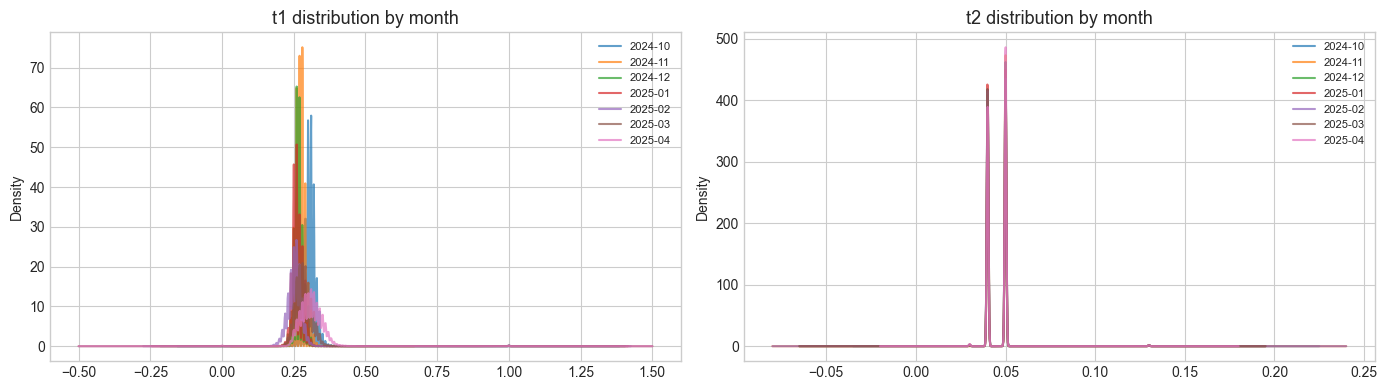

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for col, ax in zip(["t1", "t2"], axes):
    for ml in month_order:
        subset = train[train["month_label"] == ml][col].dropna()
        if len(subset) > 10:
            subset.plot.kde(ax=ax, label=ml, alpha=0.7)
    ax.set_title(f"{col} distribution by month")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

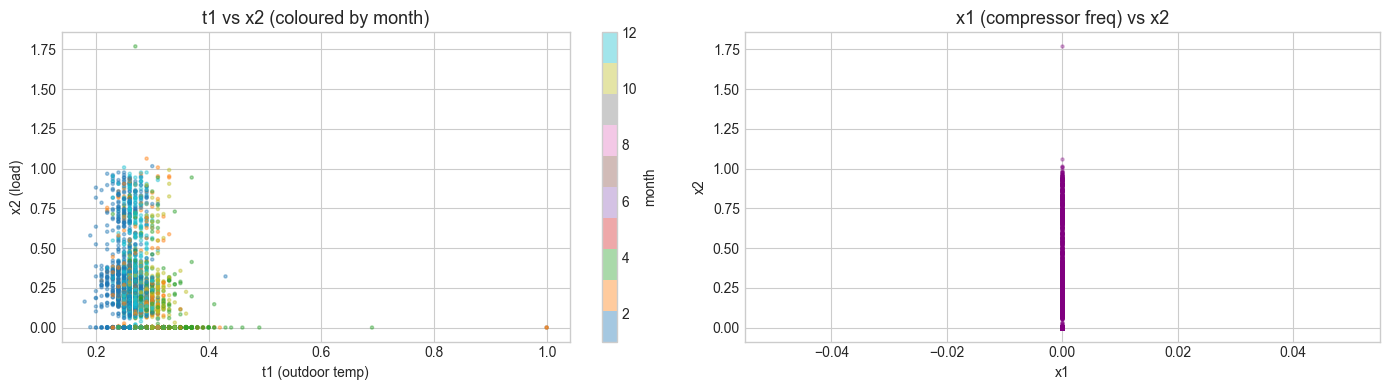

In [20]:
sample_scatter = train.sample(min(5000, len(train)), random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sc = axes[0].scatter(sample_scatter["t1"], sample_scatter["x2"],
                     c=sample_scatter["month"], cmap="tab10", alpha=0.4, s=5)
axes[0].set_title("t1 vs x2 (coloured by month)")
axes[0].set_xlabel("t1 (outdoor temp)")
axes[0].set_ylabel("x2 (load)")
plt.colorbar(sc, ax=axes[0], label="month")

axes[1].scatter(sample_scatter["x1"], sample_scatter["x2"],
                alpha=0.3, s=5, color="purple")
axes[1].set_title("x1 (compressor freq) vs x2")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.tight_layout()
plt.show()

## 6. Device & Geographic Analysis

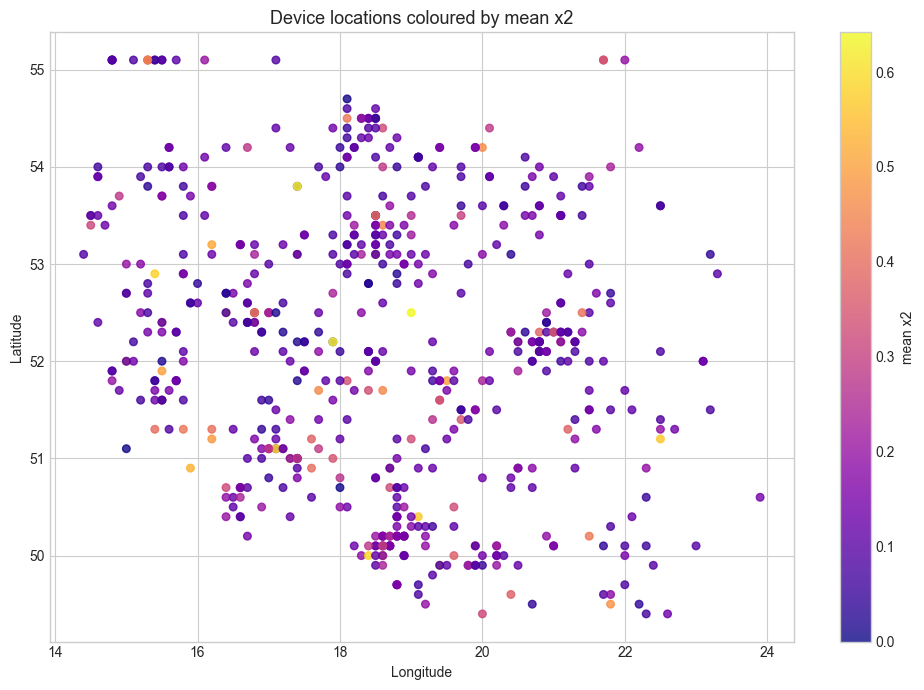

In [21]:
dev_stats = (
    train.groupby("deviceId")
    .agg(mean_x2=("x2", "mean"), lat=("latitude", "first"), lon=("longitude", "first"))
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(dev_stats["lon"], dev_stats["lat"],
                c=dev_stats["mean_x2"], cmap="plasma", s=30, alpha=0.8)
plt.colorbar(sc, ax=ax, label="mean x2")
ax.set_title("Device locations coloured by mean x2")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

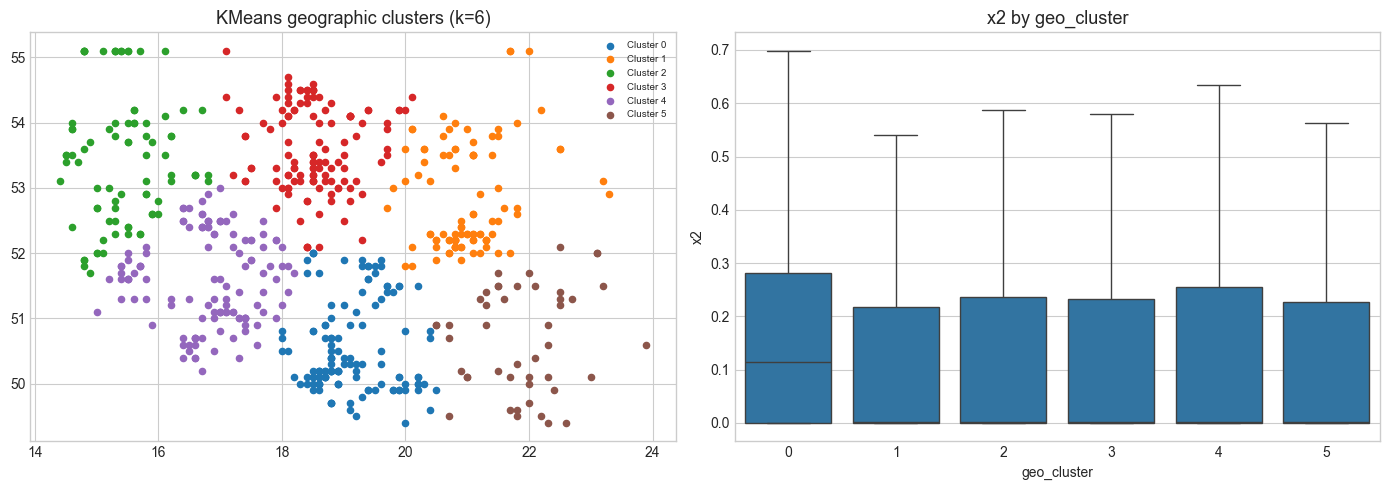

In [22]:
N_CLUSTERS = 6
km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
coords = devices[["latitude", "longitude"]].fillna(devices[["latitude","longitude"]].mean())
devices["geo_cluster"] = km.fit_predict(coords)

# Propagate to df, avoiding duplicate column issues
if "geo_cluster" in df.columns:
    df = df.drop(columns=["geo_cluster"])
df = df.merge(devices[["deviceId", "geo_cluster"]], on="deviceId", how="left")

# Refresh train slice
train = df[df["period"] == "train"].copy()
train["month"] = train["timedate"].dt.month
train["hour"]  = train["timedate"].dt.hour
train["day_of_week"] = train["timedate"].dt.dayofweek
train["month_label"] = train["timedate"].dt.to_period("M").astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl, grp in devices.groupby("geo_cluster"):
    axes[0].scatter(grp["longitude"], grp["latitude"], label=f"Cluster {cl}", s=20)
axes[0].set_title(f"KMeans geographic clusters (k={N_CLUSTERS})")
axes[0].legend(fontsize=7)

sns.boxplot(data=train, x="geo_cluster", y="x2", ax=axes[1], showfliers=False)
axes[1].set_title("x2 by geo_cluster")
plt.tight_layout()
plt.show()

## 7. Data Engineering

In [23]:
df = df.sort_values(["deviceId", "timedate"]).reset_index(drop=True)

# Temporal features
df["month"]       = df["timedate"].dt.month
df["day_of_week"] = df["timedate"].dt.dayofweek
df["hour"]        = df["timedate"].dt.hour
df["day_of_year"] = df["timedate"].dt.dayofyear
df["is_weekend"]  = df["day_of_week"] >= 5

def month_to_season(m):
    if m in (12, 1, 2): return 1  # winter
    if m in (3, 4, 5):  return 2  # spring
    if m in (6, 7, 8):  return 3  # summer
    return 4                       # autumn

df["season"] = df["month"].map(month_to_season)
print("Temporal features added.")

Temporal features added.


In [24]:
# Lag & rolling features (per device)
grp = df.groupby("deviceId", sort=False)["x2"]

df["x2_lag_1"]   = grp.shift(1)
df["x2_lag_12"]  = grp.shift(12)
df["x2_lag_288"] = grp.shift(288)

df["x2_roll_mean_12"]  = grp.transform(lambda s: s.shift(1).rolling(12,  min_periods=1).mean())
df["x2_roll_std_12"]   = grp.transform(lambda s: s.shift(1).rolling(12,  min_periods=2).std())
df["x2_roll_mean_288"] = grp.transform(lambda s: s.shift(1).rolling(288, min_periods=1).mean())

df["t1_roll_mean_12"] = (
    df.groupby("deviceId", sort=False)["t1"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).mean())
)

print("Lag & rolling features added.")

Lag & rolling features added.


In [25]:
# Device stats from train only (no leakage)
train_mask = df["period"] == "train"
device_stats = (
    df[train_mask]
    .groupby("deviceId")["x2"]
    .agg(device_mean_x2="mean", device_std_x2="std")
    .reset_index()
)

# Avoid duplicate columns on re-run
for col in ["device_mean_x2", "device_std_x2"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(device_stats, on="deviceId", how="left")
print(f"device_mean_x2 nulls: {df['device_mean_x2'].isna().sum()}")

device_mean_x2 nulls: 0


In [26]:
# Monthly aggregation — the actual prediction target
df["year_month"] = df["timedate"].dt.to_period("M")

monthly_target = (
    df[train_mask]
    .groupby(["deviceId", "year_month"])["x2"]
    .mean()
    .reset_index()
    .rename(columns={"x2": "mean_x2_per_month"})
)
print("Monthly target aggregation (train):")
monthly_target.head(5)

Monthly target aggregation (train):


,deviceId,year_month,mean_x2_per_month
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-10,0.095713
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-11,0.205218
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-12,0.246298
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-01,0.275046
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025-02,0.280997


## 8. Feature Importance Preview

In [27]:
FEATURE_COLS = [
    "month", "day_of_week", "hour", "day_of_year", "is_weekend", "season",
    "x1", "x3",
    "t1", "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9", "t10", "t11", "t12", "t13",
    "x2_lag_1", "x2_lag_12", "x2_lag_288",
    "x2_roll_mean_12", "x2_roll_std_12", "x2_roll_mean_288",
    "t1_roll_mean_12",
    "device_mean_x2", "device_std_x2",
    "geo_cluster", "latitude", "longitude",
    "deviceType",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

train_fi = df[train_mask].copy()

# Encode categoricals
for col in ["x3", "deviceType", "geo_cluster"]:
    if col in train_fi.columns:
        le = LabelEncoder()
        train_fi[col] = le.fit_transform(train_fi[col].astype(str))

X = train_fi[FEATURE_COLS].fillna(-999)
y = train_fi["x2"].fillna(0)

N = min(200_000, len(X))
idx = np.random.choice(len(X), N, replace=False)
X_s, y_s = X.iloc[idx], y.iloc[idx]

print(f"Fitting RandomForest on {N:,} rows, {len(FEATURE_COLS)} features...")

Fitting RandomForest on 200,000 rows, 34 features...


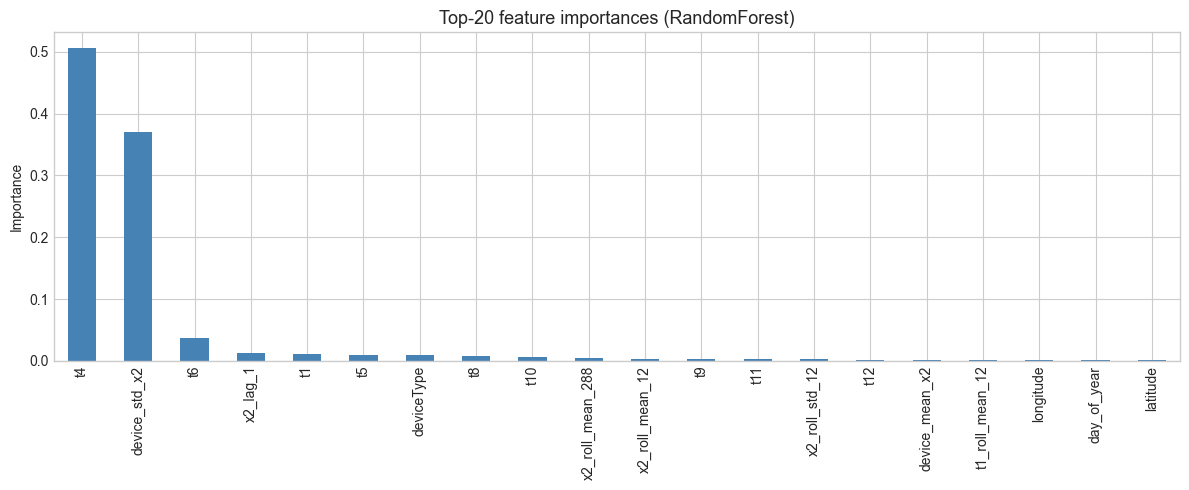

t4                  0.506489
device_std_x2       0.370935
t6                  0.036945
x2_lag_1            0.012749
t1                  0.010296
t5                  0.009145
deviceType          0.009049
t8                  0.008251
t10                 0.006493
x2_roll_mean_288    0.004340
x2_roll_mean_12     0.003656
t9                  0.003464
t11                 0.002688
x2_roll_std_12      0.002552
t12                 0.001834
device_mean_x2      0.001688
t1_roll_mean_12     0.001441
longitude           0.001015
day_of_year         0.000998
latitude            0.000881
dtype: float64


In [28]:
rf = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_s, y_s)

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
importances.head(20).plot.bar(ax=ax, color="steelblue")
ax.set_title("Top-20 feature importances (RandomForest)")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(20))

## 9. Save Engineered Dataset

In [29]:
# Convert Period dtype to string for parquet compatibility
df["year_month"] = df["year_month"].astype(str)

OUT_PATH = "data/eda_sample.parquet"
df.to_parquet(OUT_PATH, index=False)
print(f"Saved → {OUT_PATH}")
print(f"Shape: {df.shape}")
print("\nFinal columns:")
print(df.columns.tolist())

Saved → data/eda_sample.parquet
Shape: (6449732, 39)

Final columns:
['deviceId', 'timedate', 'period', 't1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9', 't10', 't11', 't12', 't13', 'x1', 'x2', 'x3', 'deviceType', 'latitude', 'longitude', 'geo_cluster', 'month', 'day_of_week', 'hour', 'day_of_year', 'is_weekend', 'season', 'x2_lag_1', 'x2_lag_12', 'x2_lag_288', 'x2_roll_mean_12', 'x2_roll_std_12', 'x2_roll_mean_288', 't1_roll_mean_12', 'device_mean_x2', 'device_std_x2', 'year_month']
